<a href="https://colab.research.google.com/github/junnishiye/SERS_2semestre_checkpoint_2/blob/main/checkpoint2_energia_renovavel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 02 — APIs, energia renovável e aprendizado de máquina

## Integrantes

| Nome | RM |
|---|---:|
| Davi | 569487 |
| Gabriel | 568910 |
| Aragão | 570529 |
| André | 571691 |
| Jun | 572079 |

Notebook desenvolvido a partir do material de apoio do professor André Tritiack, disponível no [repositório da atividade](https://github.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM). Há duas tarefas independentes: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar horária em Petrolina (PE). Em cada tarefa, três algoritmos usam exatamente a mesma divisão de treino e teste.

Os CSVs deste repositório são cópias dos arquivos disponibilizados pelo professor. O notebook roda com essas cópias para reproduzir as métricas. Defina `ATUALIZAR_DADOS = True` na célula abaixo se quiser consultar novamente as APIs e regenerar os CSVs; os resultados podem mudar com uma atualização dos dados.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [1]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [2]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [3]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


Por padrão, o notebook usa as cópias dos CSVs publicadas junto à entrega. Para consultar as APIs de novo, mude `ATUALIZAR_DADOS` para `True`. A consulta da ANEEL pode mudar conforme o cadastro é atualizado; manter os CSVs permite reproduzir exatamente os resultados apresentados.

In [4]:
# Execução reproduzível com os CSVs publicados; mude para True para regenerá-los pelas APIs.
ATUALIZAR_DADOS = False
registros_aneel = []
if ATUALIZAR_DADOS:
    for sigla in SIGLAS:
        parametros = {
            "resource_id": ID_RECURSO,
            "filters": json.dumps({"SigTipoGeracao": sigla}),
            "limit": 1200,
        }
        resposta = consultar_api(URL_ANEEL, parametros)
        if not resposta.get("success"):
            raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
        linhas = resposta["result"]["records"]
        print(f"{sigla}: {len(linhas)} linhas recebidas")
        registros_aneel.extend(linhas)
    print("Total de linhas recebidas:", len(registros_aneel))
else:
    print("ANEEL: usando o CSV versionado do repositório para reproduzir os resultados.")

ANEEL: usando o CSV versionado do repositório para reproduzir os resultados.


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [5]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
if ATUALIZAR_DADOS:
    for registro in registros_aneel:
        potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
        latitude = numero(registro.get("NumCoordNEmpreendimento"))
        longitude = numero(registro.get("NumCoordEEmpreendimento"))
        fonte = fontes.get(registro.get("SigTipoGeracao"))
        if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
            linhas_classificacao.append([potencia, latitude, longitude, fonte])
    if len(linhas_classificacao) < 90:
        raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
    print("Linhas válidas:", len(linhas_classificacao))
    print("Primeiro exemplo:", linhas_classificacao[0])

In [6]:
from pathlib import Path

ARQUIVO_ANEEL = Path("aneel_classificacao_orange.csv")
if ATUALIZAR_DADOS:
    with ARQUIVO_ANEEL.open("w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
        escritor.writerows(linhas_classificacao)
elif not ARQUIVO_ANEEL.exists():
    url_csv = "https://raw.githubusercontent.com/junnishiye/SERS_2semestre_checkpoint_2/main/aneel_classificacao_orange.csv"
    urllib.request.urlretrieve(url_csv, ARQUIVO_ANEEL)
print("CSV disponível:", ARQUIVO_ANEEL)

CSV disponível: aneel_classificacao_orange.csv


## Bibliotecas para as duas tarefas

As consultas e a criação dos CSVs acima usam a biblioteca padrão. A partir daqui usamos Pandas, gráficos e scikit-learn para analisar e comparar os modelos.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score, classification_report,
                             mean_absolute_error, mean_squared_error, r2_score)

### Reprodução dos dados

Se você abriu somente este notebook no Colab, as células anteriores baixam os CSVs da entrega. Se clonou o repositório, os arquivos locais são usados. Ativar a consulta às APIs substitui os CSVs locais pelas novas respostas.

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

## 1.1 Exploração dos dados da ANEEL

Cada linha é um empreendimento cadastrado; `potencia_kw` é potência **outorgada**, e não energia produzida. O alvo `fonte` tem três classes.

In [8]:
dados_classificacao = pd.read_csv(ARQUIVO_ANEEL)
display(dados_classificacao.head())
print("Dimensão:", dados_classificacao.shape)
print("Tipos:")
print(dados_classificacao.dtypes)
print("Valores ausentes:")
print(dados_classificacao.isna().sum())
print("Registros por classe:")
print(dados_classificacao["fonte"].value_counts())
display(dados_classificacao.describe())

Dimensão: (3876, 4)
Tipos:
potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object
Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64
Registros por classe:
fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


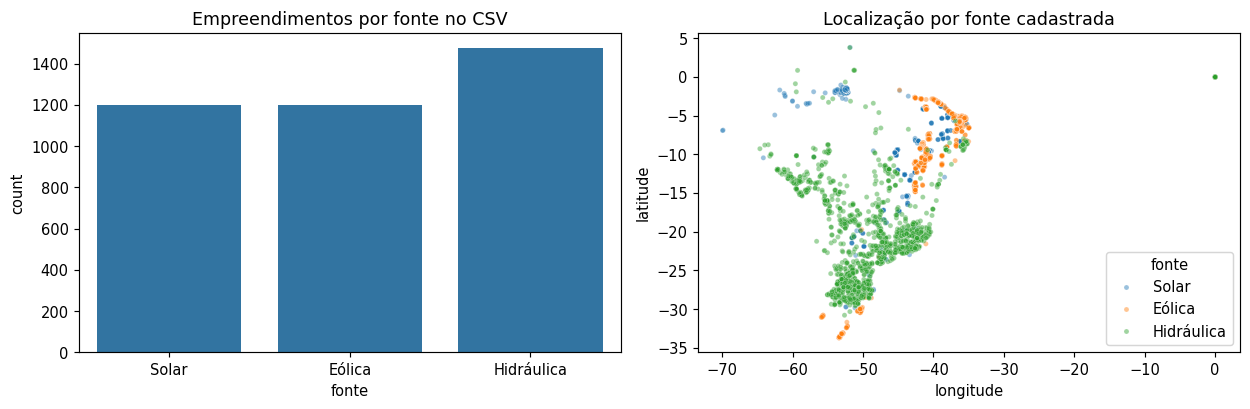

In [9]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=dados_classificacao, x="fonte", order=["Solar", "Eólica", "Hidráulica"], ax=eixos[0])
eixos[0].set_title("Empreendimentos por fonte no CSV")
sns.scatterplot(data=dados_classificacao, x="longitude", y="latitude", hue="fonte",
                alpha=0.45, s=12, ax=eixos[1])
eixos[1].set_title("Localização por fonte cadastrada")
plt.tight_layout()
plt.show()

## 1.2 Treino e avaliação dos três classificadores

`X` contém somente potência e coordenadas; `y` é a categoria da fonte. A divisão é estratificada para manter as proporções das classes. A escala para KNN e Regressão Logística é ajustada no treino por `Pipeline`, evitando usar informação do teste no ajuste.

In [10]:
entradas_classificacao = ["potencia_kw", "latitude", "longitude"]
X_class = dados_classificacao[entradas_classificacao]
y_class = dados_classificacao["fonte"]
X_class_treino, X_class_teste, y_class_treino, y_class_teste = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42, stratify=y_class
)
modelos_classificacao = {
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7)),
    "Regressão Logística": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
print(f"Treino: {len(X_class_treino)}; teste: {len(X_class_teste)}")
print("Alvos no teste:")
print(y_class_teste.value_counts())

Treino: 3100; teste: 776
Alvos no teste:
fonte
Hidráulica    296
Solar         240
Eólica        240
Name: count, dtype: int64


In [11]:
classes = ["Solar", "Eólica", "Hidráulica"]
resultados_classificacao = []
previsoes_classificacao = {}
for nome, modelo in modelos_classificacao.items():
    modelo.fit(X_class_treino, y_class_treino)
    previsoes = modelo.predict(X_class_teste)
    previsoes_classificacao[nome] = previsoes
    resultados_classificacao.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_class_teste, previsoes),
        "Precision (macro)": precision_score(y_class_teste, previsoes, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_class_teste, previsoes, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_class_teste, previsoes, average="macro", zero_division=0),
    })
comparacao_classificacao = pd.DataFrame(resultados_classificacao)
display(comparacao_classificacao.round(4))
for nome, previsoes in previsoes_classificacao.items():
    print(f"\nMétricas por classe — {nome}:")
    print(classification_report(y_class_teste, previsoes, labels=classes, zero_division=0))


Métricas por classe — KNN:
              precision    recall  f1-score   support

       Solar       0.98      0.93      0.96       240
      Eólica       0.97      0.97      0.97       240
  Hidráulica       0.95      0.99      0.97       296

    accuracy                           0.97       776
   macro avg       0.97      0.96      0.96       776
weighted avg       0.97      0.97      0.97       776


Métricas por classe — Regressão Logística:
              precision    recall  f1-score   support

       Solar       0.86      0.70      0.77       240
      Eólica       0.75      0.90      0.82       240
  Hidráulica       0.87      0.87      0.87       296

    accuracy                           0.82       776
   macro avg       0.83      0.82      0.82       776
weighted avg       0.83      0.82      0.82       776


Métricas por classe — Random Forest:
              precision    recall  f1-score   support

       Solar       1.00      0.95      0.97       240
      Eólica       

,Modelo,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,KNN,0.9652,0.9668,0.9633,0.9647
1,Regressão Logística,0.8247,0.8282,0.8214,0.8197
2,Random Forest,0.9755,0.9769,0.9741,0.9753


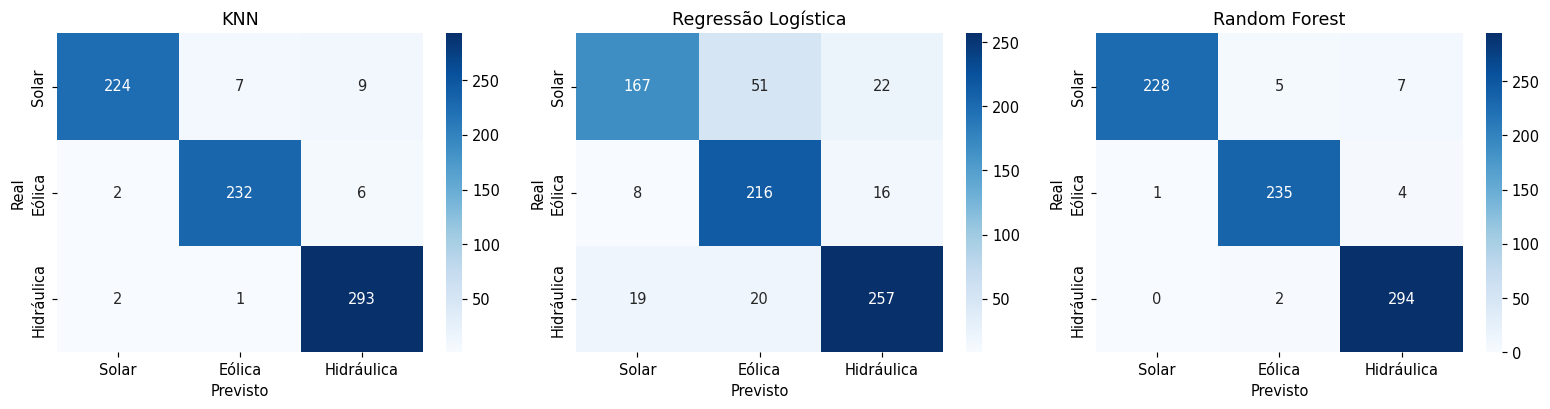

In [12]:
fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
for eixo, (nome, previsoes) in zip(eixos, previsoes_classificacao.items()):
    matriz = confusion_matrix(y_class_teste, previsoes, labels=classes)
    sns.heatmap(matriz, annot=True, fmt="d", cmap="Blues", xticklabels=classes,
                yticklabels=classes, ax=eixo)
    eixo.set_title(nome)
    eixo.set_xlabel("Previsto")
    eixo.set_ylabel("Real")
plt.tight_layout()
plt.show()

### Conclusão da classificação

Usamos média **macro** em Precision, Recall e F1: cada uma das três classes tem o mesmo peso na média. No teste estratificado (776 empreendimentos), **Random Forest** alcançou Accuracy **0,9755** e F1 macro **0,9753**; KNN obteve **0,9652** e **0,9647**; Regressão Logística, **0,8247** e **0,8197**. Escolhemos Random Forest para estes dados. Na sua matriz, 5 solares foram confundidos com eólicos, 7 com hidráulicos; 4 eólicos com hidráulicos e 2 hidráulicos com eólicos. Esses erros mostram que as classes se sobrepõem em potência e localização. O resultado mede acerto neste recorte do cadastro; potência outorgada e coordenadas não identificam com certeza a tecnologia de uma nova usina, e a amostra foi limitada por tipo na consulta.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [13]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [14]:
if ATUALIZAR_DADOS:
    resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
    if "hourly" not in resposta_meteo:
        raise ValueError("Resposta sem a seção hourly")
    horas_api = resposta_meteo["hourly"]
    print("Campos recebidos:", list(horas_api))
    print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
    print("Quantidade de horários:", len(horas_api["time"]))
else:
    print("Open-Meteo: usando o CSV versionado do repositório para reproduzir os resultados.")

Open-Meteo: usando o CSV versionado do repositório para reproduzir os resultados.


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [15]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
if ATUALIZAR_DADOS:
    for indice, data_hora in enumerate(horas_api["time"]):
        hora = int(data_hora[11:13])
        valores = [horas_api[nome][indice] for nome in nomes_api]
        if 7 <= hora <= 17 and all(valor is not None for valor in valores):
            linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
    if len(linhas_regressao) < 100:
        raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
    print("Horas válidas:", len(linhas_regressao))
    print("Primeiro exemplo:", linhas_regressao[0])

In [16]:
ARQUIVO_METEO = Path("meteo_regressao_orange.csv")
if ATUALIZAR_DADOS:
    with ARQUIVO_METEO.open("w", newline="", encoding="utf-8-sig") as arquivo:
        escritor = csv.writer(arquivo)
        escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                           "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
        escritor.writerows(linhas_regressao)
elif not ARQUIVO_METEO.exists():
    url_csv = "https://raw.githubusercontent.com/junnishiye/SERS_2semestre_checkpoint_2/main/meteo_regressao_orange.csv"
    urllib.request.urlretrieve(url_csv, ARQUIVO_METEO)
print("CSV disponível:", ARQUIVO_METEO)

CSV disponível: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## 2.1 Exploração das horas de Petrolina

O alvo `radiacao_w_m2` é a radiação solar horizontal média da hora anterior, em W/m². A coluna `data_hora` orienta a ordem do tempo, enquanto `hora` pode ser usada pelo modelo como entrada.

In [17]:
dados_regressao = pd.read_csv(ARQUIVO_METEO)
dados_regressao["data_hora"] = pd.to_datetime(dados_regressao["data_hora"])
dados_regressao = dados_regressao.sort_values("data_hora").reset_index(drop=True)
display(dados_regressao.head())
print("Dimensão:", dados_regressao.shape)
print("Período:", dados_regressao["data_hora"].min(), "a", dados_regressao["data_hora"].max())
print("Tipos:")
print(dados_regressao.dtypes)
print("Valores ausentes:")
print(dados_regressao.isna().sum())
display(dados_regressao.describe())

Dimensão: (1001, 7)
Período: 2025-04-01 07:00:00 a 2025-06-30 17:00:00
Tipos:
data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object
Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


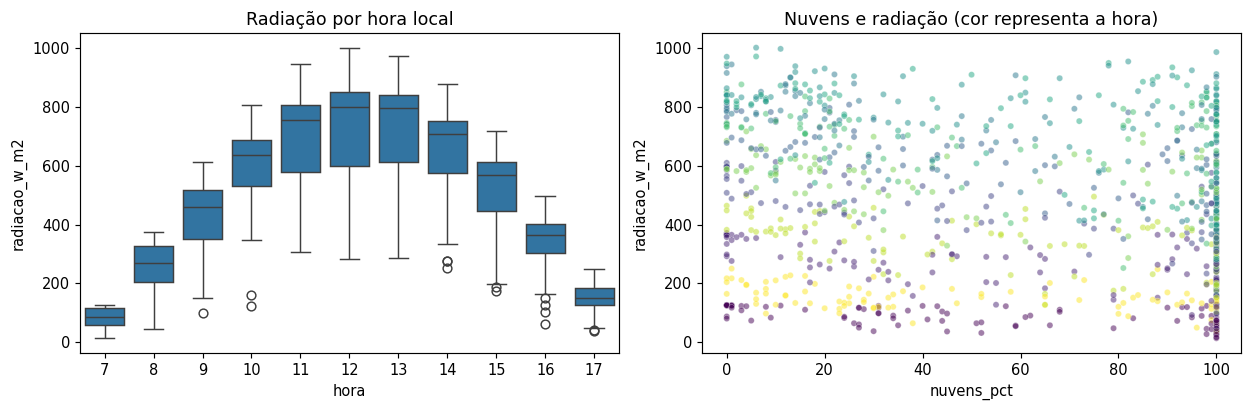

In [18]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=dados_regressao, x="hora", y="radiacao_w_m2", ax=eixos[0])
eixos[0].set_title("Radiação por hora local")
sns.scatterplot(data=dados_regressao, x="nuvens_pct", y="radiacao_w_m2", hue="hora",
                palette="viridis", alpha=0.5, s=18, ax=eixos[1], legend=False)
eixos[1].set_title("Nuvens e radiação (cor representa a hora)")
plt.tight_layout()
plt.show()

## 2.2 Treino cronológico e comparação dos três regressores

As primeiras 800 horas são o treino; as últimas 201 horas são o teste. Nenhum embaralhamento ou ajuste com o teste é feito. `radiacao_w_m2` fica somente em `y`, sem aparecer como entrada ou transformação de entrada.

In [19]:
entradas_regressao = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_reg = dados_regressao[entradas_regressao]
y_reg = dados_regressao["radiacao_w_m2"]
limite = int(len(dados_regressao) * 0.8)
X_reg_treino, X_reg_teste = X_reg.iloc[:limite], X_reg.iloc[limite:]
y_reg_treino, y_reg_teste = y_reg.iloc[:limite], y_reg.iloc[limite:]
modelos_regressao = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                                            random_state=42, n_jobs=-1),
}
print(f"Treino: {len(X_reg_treino)} horas; teste: {len(X_reg_teste)} horas")
print("Último horário do treino:", dados_regressao.loc[limite - 1, "data_hora"])
print("Primeiro horário do teste:", dados_regressao.loc[limite, "data_hora"])

Treino: 800 horas; teste: 201 horas
Último horário do treino: 2025-06-12 14:00:00
Primeiro horário do teste: 2025-06-12 15:00:00


In [20]:
resultados_regressao = []
previsoes_regressao = {}
for nome, modelo in modelos_regressao.items():
    modelo.fit(X_reg_treino, y_reg_treino)
    previsoes = modelo.predict(X_reg_teste)
    previsoes_regressao[nome] = previsoes
    resultados_regressao.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_reg_teste, previsoes),
        "MSE ((W/m²)²)": mean_squared_error(y_reg_teste, previsoes),
        "R²": r2_score(y_reg_teste, previsoes),
    })
comparacao_regressao = pd.DataFrame(resultados_regressao)
display(comparacao_regressao.round(4))

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.2049,30034.2011,0.3598
1,Árvore de Decisão,87.1374,14005.8815,0.7015
2,Random Forest,67.1988,7458.5438,0.8410


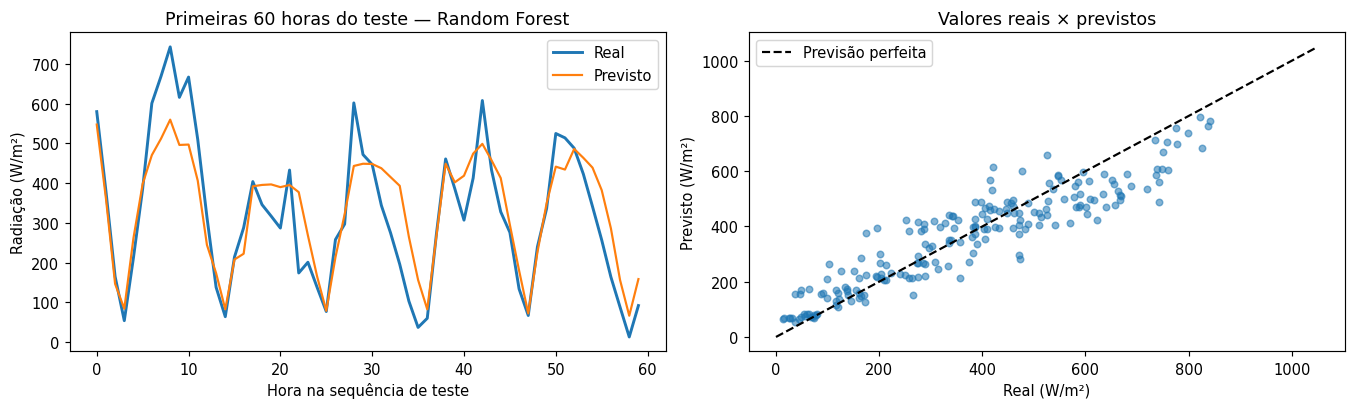

In [21]:
melhor_nome = comparacao_regressao.sort_values("MAE (W/m²)").iloc[0]["Modelo"]
melhor_previsao = previsoes_regressao[melhor_nome]
fig, eixos = plt.subplots(1, 2, figsize=(13, 4))
eixos[0].plot(y_reg_teste.to_numpy()[:60], label="Real", linewidth=2)
eixos[0].plot(melhor_previsao[:60], label="Previsto", linewidth=1.5)
eixos[0].set_title(f"Primeiras 60 horas do teste — {melhor_nome}")
eixos[0].set_xlabel("Hora na sequência de teste")
eixos[0].set_ylabel("Radiação (W/m²)")
eixos[0].legend()
eixos[1].scatter(y_reg_teste, melhor_previsao, alpha=0.55, s=20)
eixos[1].plot([0, 1050], [0, 1050], "--", color="black", label="Previsão perfeita")
eixos[1].set_title("Valores reais × previstos")
eixos[1].set_xlabel("Real (W/m²)")
eixos[1].set_ylabel("Previsto (W/m²)")
eixos[1].legend()
plt.tight_layout()
plt.show()

### Conclusão da regressão

No teste das últimas 201 horas, **Random Forest** teve o menor MAE (**67,20 W/m²**), menor MSE (**7.458,54 (W/m²)²**) e maior R² (**0,8410**). A Árvore obteve MAE **87,14** e R² **0,7015**; a Regressão Linear, MAE **145,20** e R² **0,3598**. A hora ajuda a descrever o ciclo diário: manhã e fim de tarde tendem a ter menos radiação do que o meio do dia. Ainda há dispersão nos gráficos; nuvens, condições meteorológicas e características sazonais alteram a radiação. Radiação horizontal em W/m² não é energia elétrica produzida: para estimar geração seriam necessários, entre outros fatores, área, orientação, eficiência, perdas e intervalo de operação do sistema fotovoltaico. Os dados históricos são estimativas meteorológicas, não medições de um painel.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)